<a href="https://colab.research.google.com/github/DidarulIslamok/AcadGIS/blob/main/Thesis_Aanalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
import pandas as pd

# ১. ড্রাইভ মাউন্ট করুন (এটি আপনার ফাইলগুলো Colab-এ নিয়ে আসবে)
drive.mount('/content/drive')

# ২. ফাইলগুলো লোড করুন (ফাইলের পাথ ঠিক আছে কিনা নিশ্চিত হয়ে নিন)
# ড্রাইভের GEE_Exports ফোল্ডারে ফাইলগুলো চেক করুন
ndvi_df = pd.read_csv('/content/drive/MyDrive/GEE_Exports/BARIND8_NDVI_QCMASKED.csv')
et_df = pd.read_csv('/content/drive/MyDrive/GEE_Exports/BARIND8_ET_GAPFILLED_QCMASKED.csv')
lst_df = pd.read_csv('/content/drive/MyDrive/GEE_Exports/BARIND8_LST_QCMASKED.csv')

# ৩. নাল ভ্যালু এবং ডাটা সাইজ চেক করা
print("NDVI Nulls:", ndvi_df.isnull().sum())
print("ET Nulls:", et_df.isnull().sum())
print("LST Nulls:", lst_df.isnull().sum())

Mounted at /content/drive
NDVI Nulls: system:index      0
date              0
mean            756
station           0
.geo              0
dtype: int64
ET Nulls: system:index        0
date                0
had_valid_pixels    0
mean                1
product_used        0
station             0
.geo                0
dtype: int64
LST Nulls: system:index           0
date                   0
had_valid_pixels       0
mean                1337
station                0
.geo                   0
dtype: int64


In [2]:
import pandas as pd
import os

# আপনার ফাইল পাথগুলো চেক করে নিন (ড্রাইভ মাউন্ট করা থাকলে এই পাথটি কাজ করবে)
base_path = '/content/drive/MyDrive/GEE_Exports/'

# ফাইলগুলো লোড করুন
ndvi_df = pd.read_csv(base_path + 'BARIND8_NDVI_QCMASKED.csv')
et_df = pd.read_csv(base_path + 'BARIND8_ET_GAPFILLED_QCMASKED.csv')
lst_df = pd.read_csv(base_path + 'BARIND8_LST_QCMASKED.csv')

# মার্চ করার আগে ডেট এবং স্টেশন ফরম্যাট ঠিক করে নিন
merged_df = ndvi_df.merge(et_df[['date', 'station', 'mean']], on=['date', 'station'], suffixes=('_ndvi', '_et')) \
                   .merge(lst_df[['date', 'station', 'mean']], on=['date', 'station'])
merged_df.rename(columns={'mean_ndvi': 'NDVI', 'mean_et': 'ET', 'mean': 'LST'}, inplace=True)

# ১. শতাংশের হিসেব (Null %)
total_rows = len(merged_df)
null_percentage = (merged_df.isnull().sum() / total_rows) * 100

# ২. ডেসক্রিপটিভ স্ট্যাটিস্টিকস
descriptive = merged_df.describe()

print("--- ডাটার নাল ভ্যালুর শতাংশ ---")
print(null_percentage)
print("\n--- ডেসক্রিপটিভ অ্যানালাইসিস ---")
print(descriptive)

--- ডাটার নাল ভ্যালুর শতাংশ ---
system:index     0.000000
date             0.000000
NDVI            16.520979
station          0.000000
.geo             0.000000
ET               0.021853
LST             29.217657
dtype: float64

--- ডেসক্রিপটিভ অ্যানালাইসিস ---
              NDVI           ET           LST
count  3820.000000  4575.000000   3239.000000
mean   4891.582294   138.046388  15071.234794
std    1231.745055    85.499114    189.995958
min   -1512.812328     3.259151  14553.669767
25%    4015.688951    62.834457  14928.890639
50%    4749.200565   115.283927  15092.840440
75%    5718.086775   221.500816  15200.338495
max    8458.869390   349.179794  15818.437333


In [3]:
# ১. মার্জ করা ডাটাফ্রেমের তারিখকে টাইমস্ট্যাম্পে রূপান্তর
merged_df['date'] = pd.to_datetime(merged_df['date'])

# ২. প্রতিটি স্টেশনের জন্য মিসিং ডাটা চেক করা
missing_data = merged_df[merged_df.isnull().any(axis=1)]

# ৩. কোন স্টেশনে কতগুলো রো মিসিং তা দেখা
print("--- স্টেশন অনুযায়ী মিসিং রো-এর সংখ্যা ---")
print(missing_data.groupby('station').size())

# ৪. গ্যাপ ভিজ্যুয়ালাইজ করার জন্য একটি স্যাম্পল আউটপুট
print("\n--- গ্যাপের স্যাম্পল (প্রথম ১০টি মিসিং ডেটা) ---")
print(missing_data[['date', 'station', 'NDVI', 'ET', 'LST']].head(10))

--- স্টেশন অনুযায়ী মিসিং রো-এর সংখ্যা ---
station
Badalgachhi    158
Bogura         192
Dinajpur       182
Ishwardi       161
Rajshahi       144
Rangpur        181
Saidpur        168
Tarash         155
dtype: int64

--- গ্যাপের স্যাম্পল (প্রথম ১০টি মিসিং ডেটা) ---
         date      station         NDVI          ET  LST
49 2000-05-24     Dinajpur          NaN  166.083478  NaN
50 2000-05-24      Saidpur  4849.727250  146.144166  NaN
51 2000-05-24     Rajshahi  3164.572077  108.507903  NaN
52 2000-05-24       Bogura  4269.029498  179.934829  NaN
53 2000-05-24     Ishwardi  5586.393282  150.213479  NaN
54 2000-05-24  Badalgachhi  4408.328838  142.507326  NaN
55 2000-05-24       Tarash  2917.085615  151.103999  NaN
56 2000-06-09      Rangpur  4419.181818  191.374373  NaN
57 2000-06-09     Dinajpur  5033.610105  200.192621  NaN
58 2000-06-09      Saidpur  4182.108114  192.799622  NaN


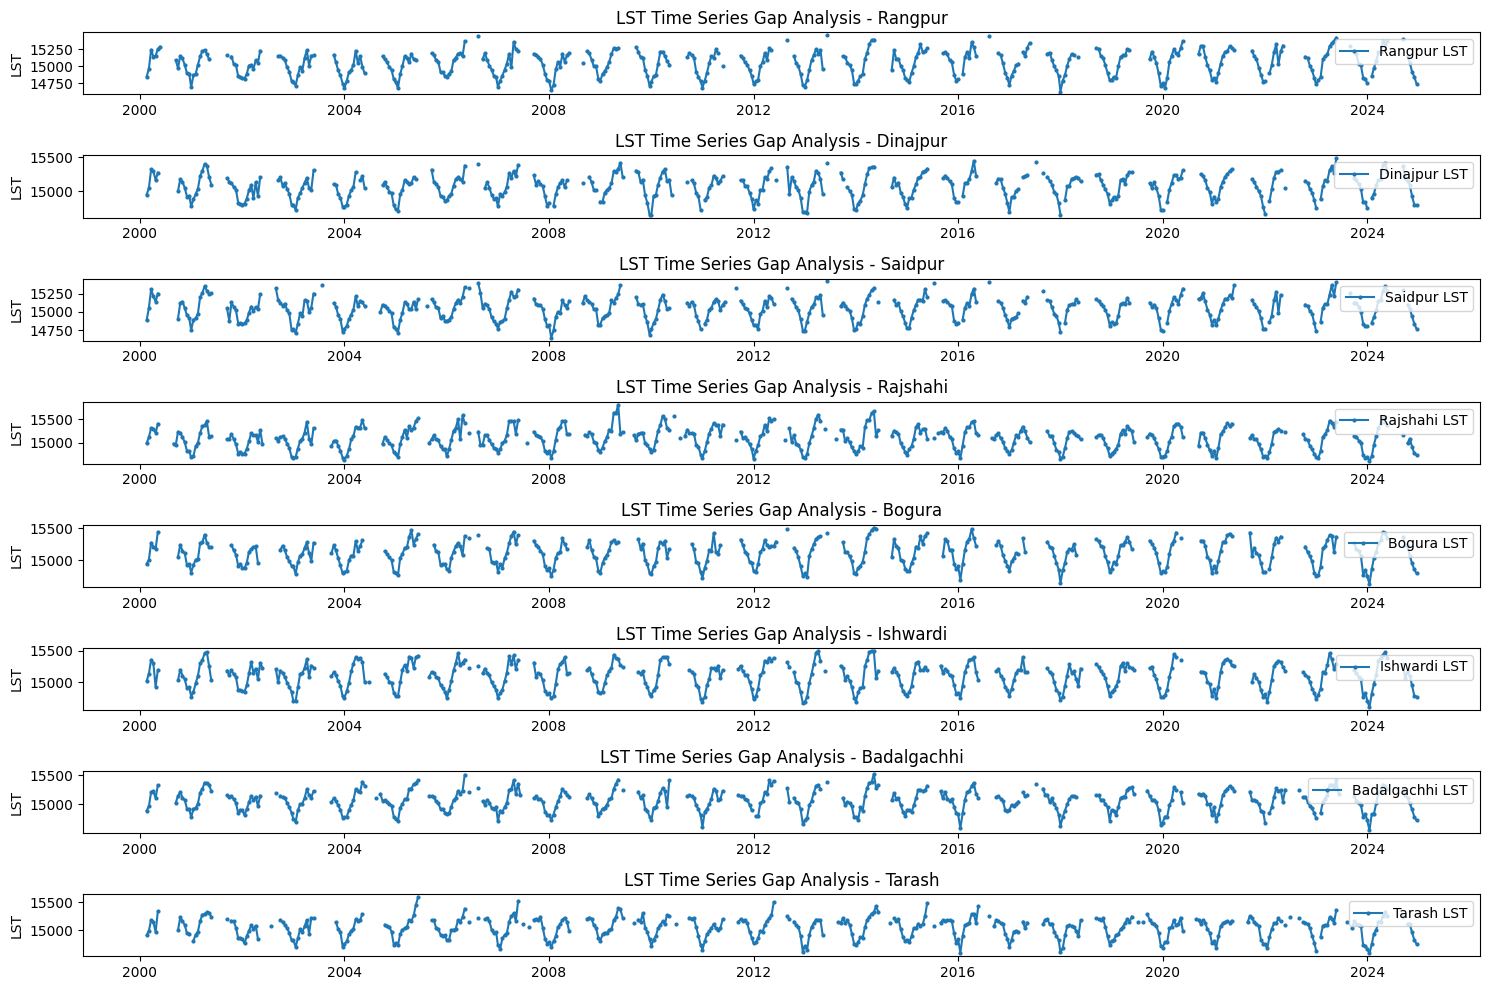

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

# ১. ডাটাফ্রেমের 'date' কলামটিকে datetime ফরম্যাটে কনভার্ট করুন
merged_df['date'] = pd.to_datetime(merged_df['date'])

# ২. প্রতিটি স্টেশনের জন্য লুপ চালিয়ে প্লট করুন
stations = merged_df['station'].unique()

plt.figure(figsize=(15, 10))

for i, station in enumerate(stations):
    plt.subplot(len(stations), 1, i + 1)
    station_data = merged_df[merged_df['station'] == station]

    # শুধু LST প্লট করছি কারণ এতেই গ্যাপ সবচেয়ে বেশি
    plt.plot(station_data['date'], station_data['LST'], label=f'{station} LST', marker='o', markersize=2, linestyle='-')
    plt.title(f'LST Time Series Gap Analysis - {station}')
    plt.ylabel('LST')
    plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

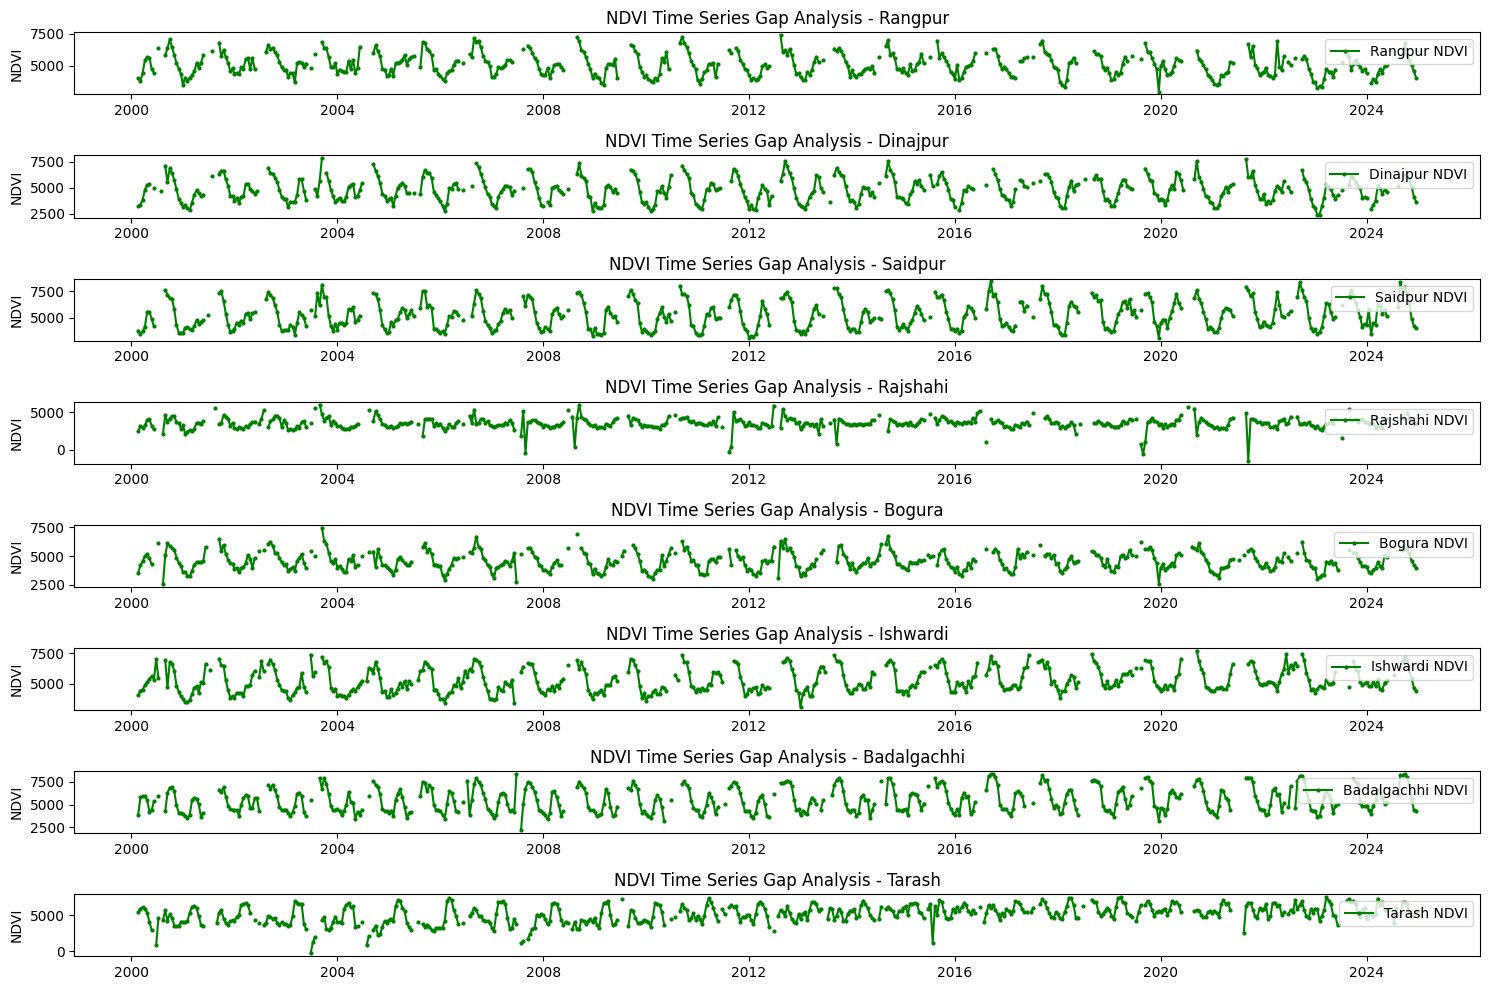

In [5]:
# NDVI-এর জন্য টাইম সিরিজ গ্যাপ ভিজ্যুয়ালাইজেশন
plt.figure(figsize=(15, 10))

for i, station in enumerate(stations):
    plt.subplot(len(stations), 1, i + 1)
    station_data = merged_df[merged_df['station'] == station]

    # NDVI প্লট করছি
    plt.plot(station_data['date'], station_data['NDVI'], label=f'{station} NDVI', color='green', marker='o', markersize=2, linestyle='-')
    plt.title(f'NDVI Time Series Gap Analysis - {station}')
    plt.ylabel('NDVI')
    plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

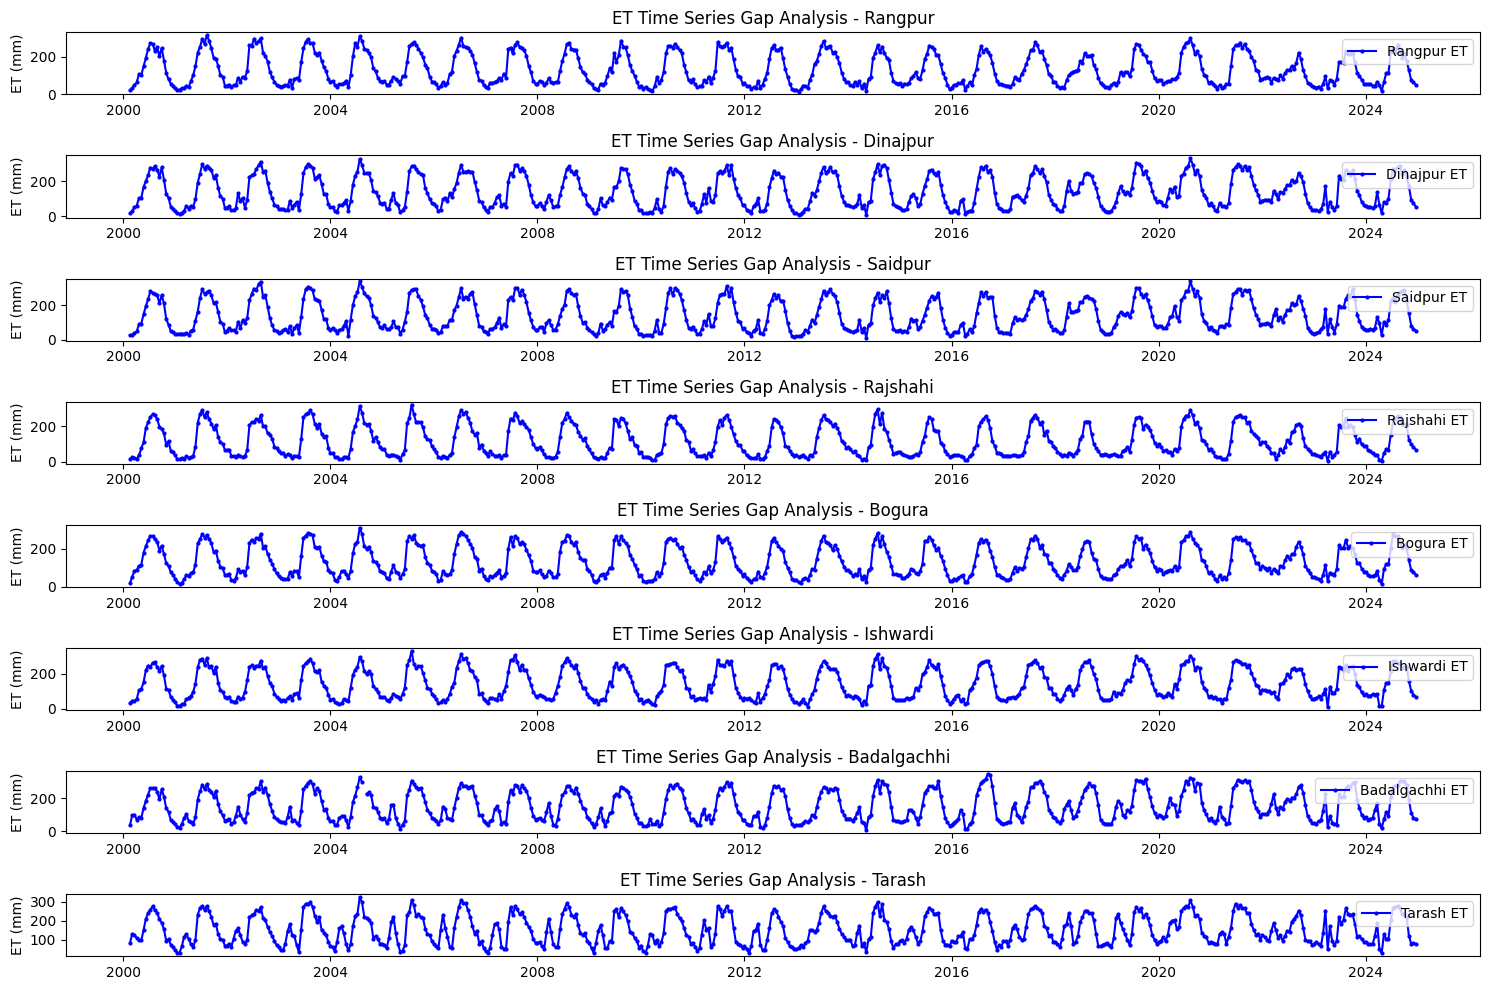

In [9]:
# ET-এর জন্য টাইম সিরিজ গ্যাপ ভিজ্যুয়ালাইজেশন
plt.figure(figsize=(15, 10))

for i, station in enumerate(stations):
    plt.subplot(len(stations), 1, i + 1)
    station_data = merged_df[merged_df['station'] == station]

    # ET প্লট করছি
    plt.plot(station_data['date'], station_data['ET'], label=f'{station} ET', color='blue', marker='o', markersize=2, linestyle='-')
    plt.title(f'ET Time Series Gap Analysis - {station}')
    plt.ylabel('ET (mm)')
    plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [10]:
merged_df['NDVI_real'] = merged_df['NDVI'] * 0.0001
merged_df['LST_C'] = (merged_df['LST'] * 0.02) - 273.15  # Kelvin -> Celsius
merged_df['ET_mm'] = merged_df['ET'] * 0.1

In [11]:
# ============================================================================
# STEP 2: FILTER, SCALE, GAP-FILL (small gaps only)
# Feeds directly into the KMO/Bartlett + PCA-VSI pipeline already built.
# ============================================================================
import pandas as pd
import numpy as np

# --- 1. Lock to the 8 real Barind Tract stations, drop everything else ---
BARIND_8 = ['Rangpur', 'Dinajpur', 'Saidpur', 'Rajshahi',
            'Bogura', 'Ishwardi', 'Badalgachhi', 'Tarash']

print(f"Stations in merged_df before filtering: {sorted(merged_df['station'].unique())}")
merged_df = merged_df[merged_df['station'].isin(BARIND_8)].copy()
print(f"Stations after filtering: {sorted(merged_df['station'].unique())}")
print(f"Rows remaining: {len(merged_df)}")

assert set(merged_df['station'].unique()) == set(BARIND_8), \
    "Station name mismatch -- check spelling/casing against your GEE export before proceeding."

# --- 2. Apply MODIS scale factors (raw digital numbers -> physical units) ---
merged_df['NDVI_real'] = merged_df['NDVI'] * 0.0001
merged_df['LST_C']     = (merged_df['LST'] * 0.02) - 273.15   # Kelvin -> Celsius
merged_df['ET_mm']     = merged_df['ET'] * 0.1

print("\n--- Scaled ranges (sanity check) ---")
print(f"NDVI_real: {merged_df['NDVI_real'].min():.3f} to {merged_df['NDVI_real'].max():.3f}  "
      f"(expect roughly -0.2 to 0.9)")
print(f"LST_C:     {merged_df['LST_C'].min():.1f} to {merged_df['LST_C'].max():.1f}  "
      f"(expect roughly 5 to 50 C for Bangladesh)")
print(f"ET_mm:     {merged_df['ET_mm'].min():.2f} to {merged_df['ET_mm'].max():.2f}  "
      f"(expect roughly 0 to 35 mm per 8-day period)")

# --- 3. Gap-fill ONLY small gaps (<=3 consecutive missing steps per station) ---
# Interpolating across large gaps invents a trend that isn't there. A short
# gap (a cloudy fortnight) is safe to linearly interpolate; a long gap
# (months) should stay missing rather than be quietly fabricated.
merged_df = merged_df.sort_values(['station', 'date'])

def gap_fill_small_only(group, cols, max_gap=3):
    group = group.sort_values('date').reset_index(drop=True)
    for col in cols:
        interpolated = group[col].interpolate(method='linear', limit=max_gap, limit_direction='both')
        group[col] = interpolated
    return group

target_cols = ['NDVI_real', 'LST_C', 'ET_mm']
merged_df = merged_df.groupby('station', group_keys=False).apply(
    lambda g: gap_fill_small_only(g, target_cols, max_gap=3)
)

remaining_nulls = merged_df[target_cols].isnull().sum()
print(f"\nRemaining nulls after small-gap fill (large gaps intentionally left as NaN):")
print(remaining_nulls)
print(f"\nRows that will need to be dropped before PCA (any remaining null): "
      f"{merged_df[target_cols].isnull().any(axis=1).sum()} out of {len(merged_df)}")

# --- 4. Save the clean, scoped, scaled dataset ---
merged_df.to_csv('BARIND8_ANALYSIS_READY.csv', index=False)
print("\nSaved: BARIND8_ANALYSIS_READY.csv")
print("This is the file the KMO/Bartlett + PCA-VSI pipeline should read from next.")

Stations in merged_df before filtering: ['Badalgachhi', 'Bogura', 'Dinajpur', 'Ishwardi', 'Rajshahi', 'Rangpur', 'Saidpur', 'Tarash']
Stations after filtering: ['Badalgachhi', 'Bogura', 'Dinajpur', 'Ishwardi', 'Rajshahi', 'Rangpur', 'Saidpur', 'Tarash']
Rows remaining: 4576

--- Scaled ranges (sanity check) ---
NDVI_real: -0.151 to 0.846  (expect roughly -0.2 to 0.9)
LST_C:     17.9 to 43.2  (expect roughly 5 to 50 C for Bangladesh)
ET_mm:     0.33 to 34.92  (expect roughly 0 to 35 mm per 8-day period)

Remaining nulls after small-gap fill (large gaps intentionally left as NaN):
NDVI_real      1
LST_C        117
ET_mm          0
dtype: int64

Rows that will need to be dropped before PCA (any remaining null): 117 out of 4576

Saved: BARIND8_ANALYSIS_READY.csv
This is the file the KMO/Bartlett + PCA-VSI pipeline should read from next.


/tmp/ipykernel_916/3629167222.py:47: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  merged_df = merged_df.groupby('station', group_keys=False).apply(


In [12]:
# ============================================================================
# STEP 3: KMO/BARTLETT VALIDITY CHECK + CORRECTED PCA
# Reads BARIND8_ANALYSIS_READY.csv from Step 2.
# ============================================================================
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

try:
    from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity
except ImportError:
    import sys, os
    os.system(f"{sys.executable} -m pip install factor_analyzer --break-system-packages")
    from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

df = pd.read_csv('BARIND8_ANALYSIS_READY.csv')
df['date'] = pd.to_datetime(df['date'])

features = ['NDVI_real', 'LST_C', 'ET_mm']
clean = df.dropna(subset=features).copy()
print(f"Rows going into PCA: {len(clean)} (dropped {len(df) - len(clean)} with remaining large gaps)")

# ----------------------------------------------------------------------
# 1. KMO + BARTLETT -- run ONCE on the full clean dataset, report honestly
# ----------------------------------------------------------------------
kmo_all, kmo_model = calculate_kmo(clean[features])
chi_square, p_value = calculate_bartlett_sphericity(clean[features])

print(f"\n--- PCA SUITABILITY CHECK (whole dataset) ---")
print(f"KMO = {kmo_model:.3f}  (threshold: >0.5 acceptable, >0.6 good)")
print(f"Bartlett's test: chi-sq = {chi_square:.1f}, p = {p_value:.4g}  (need p < 0.05)")

if kmo_model < 0.5:
    print("WARNING: KMO below 0.5 -- PCA is not statistically justified on this data.")
    print("Report this honestly. Do not proceed with PCA as if this passed.")
elif kmo_model < 0.6:
    print("KMO is marginal (0.5-0.6) -- PCA is defensible but should be reported as such,")
    print("not presented as ideal.")
else:
    print("KMO indicates PCA is well-suited to this data.")

# ----------------------------------------------------------------------
# 2. PCA -- let variance explained decide component count, don't fix it
# ----------------------------------------------------------------------
scaler = StandardScaler()
scaled = scaler.fit_transform(clean[features])

pca_full = PCA(n_components=3)
pca_full.fit(scaled)

print(f"\n--- VARIANCE EXPLAINED (all 3 components) ---")
for i, var in enumerate(pca_full.explained_variance_ratio_):
    eigval = pca_full.explained_variance_[i]
    print(f"PC{i+1}: {var*100:.1f}% variance, eigenvalue = {eigval:.3f}")

cum_var_2 = pca_full.explained_variance_ratio_[:2].sum() * 100
kaiser_components = (pca_full.explained_variance_ > 1).sum()

print(f"\nCumulative variance (PC1+PC2): {cum_var_2:.1f}%")
print(f"Components with eigenvalue > 1 (Kaiser criterion): {kaiser_components}")
print("\nDecision rule: if PC1 alone explains a clear majority AND all three")
print("variables load with the same sign, use PC1 alone as the index -- this")
print("is standard practice for 3-variable composite indices in the literature.")
print("Only combine PC1+PC2 if PC2 is separately interpretable (e.g. represents")
print("a distinct physical contrast, not just leftover noise).")

# ----------------------------------------------------------------------
# 3. Sign-correct loadings so higher score = more stress, consistently
# ----------------------------------------------------------------------
comp1 = pca_full.components_[0].copy()
lst_idx = features.index('LST_C')
if comp1[lst_idx] < 0:
    comp1 = -comp1
    print("\nPC1 sign flipped so LST loads positive (higher LST = more stress).")

print(f"\n--- PC1 LOADINGS (sign-corrected) ---")
for f, loading in zip(features, comp1):
    print(f"  {f}: {loading:.3f}")
print("Expect: LST positive, NDVI negative, ET negative (all consistent with 'more stress').")
print("If NDVI or ET loads positive here, that's a real finding to report and explain,")
print("not something to silently flip to match expectation.")

# ----------------------------------------------------------------------
# 4. Compute PC1 score as the candidate index (before deciding on PC2)
# ----------------------------------------------------------------------
clean['PC1_score'] = scaled @ comp1
clean['VSI_PC1only'] = (clean['PC1_score'] - clean['PC1_score'].min()) / \
                        (clean['PC1_score'].max() - clean['PC1_score'].min())

clean.to_csv('BARIND8_PCA_STAGE.csv', index=False)
print(f"\nSaved BARIND8_PCA_STAGE.csv with PC1-based VSI.")
print("Review the variance/loading output above, then tell me whether PC1 alone")
print("looks sufficient or whether PC2 needs to be brought in -- next step is the")
print("honest lag correlation against SPI, which depends on this decision.")

Rows going into PCA: 4459 (dropped 117 with remaining large gaps)

--- PCA SUITABILITY CHECK (whole dataset) ---
KMO = 0.593  (threshold: >0.5 acceptable, >0.6 good)
Bartlett's test: chi-sq = 2615.9, p = 0  (need p < 0.05)
KMO is marginal (0.5-0.6) -- PCA is defensible but should be reported as such,
not presented as ideal.

--- VARIANCE EXPLAINED (all 3 components) ---
PC1: 61.1% variance, eigenvalue = 1.833
PC2: 25.9% variance, eigenvalue = 0.778
PC3: 13.0% variance, eigenvalue = 0.390

Cumulative variance (PC1+PC2): 87.0%
Components with eigenvalue > 1 (Kaiser criterion): 1

Decision rule: if PC1 alone explains a clear majority AND all three
variables load with the same sign, use PC1 alone as the index -- this
is standard practice for 3-variable composite indices in the literature.
Only combine PC1+PC2 if PC2 is separately interpretable (e.g. represents
a distinct physical contrast, not just leftover noise).

--- PC1 LOADINGS (sign-corrected) ---
  NDVI_real: 0.614
  LST_C: 0.465
  

In [13]:
# ============================================================================
# STEP 3B: DESEASONALIZE BEFORE PCA
# Fixes the seasonal-cycle contamination found in the first PCA run.
# Without this, PC1 measures "what month is it" instead of "how stressed
# is this station relative to normal for this time of year" -- and any
# later correlation against SPI would be partly spurious (both indices
# tracking the same seasonal cycle rather than genuine drought departure).
# ============================================================================
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

df = pd.read_csv('BARIND8_ANALYSIS_READY.csv')
df['date'] = pd.to_datetime(df['date'])
features = ['NDVI_real', 'LST_C', 'ET_mm']

clean = df.dropna(subset=features).copy()

# --- 1. Build a "day-of-year" bucket to define climatology ---
# 16-day MODIS composites don't align to calendar months cleanly, so use
# day-of-year binned into the same 16-day structure instead of calendar month.
clean['doy'] = clean['date'].dt.dayofyear
clean['doy_bin'] = (clean['doy'] // 16) * 16   # groups into ~16-day bins across years

# --- 2. Climatology = mean and std per station per doy_bin, across ALL years ---
climatology = clean.groupby(['station', 'doy_bin'])[features].agg(['mean', 'std'])
climatology.columns = ['_'.join(c) for c in climatology.columns]
climatology = climatology.reset_index()

clean = clean.merge(climatology, on=['station', 'doy_bin'], how='left')

# --- 3. Compute anomaly z-scores: (value - climatological mean) / climatological std ---
for f in features:
    std_col = f'{f}_std'
    clean[std_col] = clean[std_col].replace(0, np.nan)  # avoid divide-by-zero
    clean[f'{f}_anomaly'] = (clean[f] - clean[f'{f}_mean']) / clean[std_col]

anomaly_features = [f'{f}_anomaly' for f in features]
clean_anom = clean.dropna(subset=anomaly_features).copy()
print(f"Rows with valid anomalies: {len(clean_anom)} (need enough years per doy_bin "
      f"per station for std to be meaningful -- check this isn't dropping too much)")

# --- 4. Re-run KMO/Bartlett and PCA on the ANOMALIES, not raw values ---
kmo_all, kmo_model = calculate_kmo(clean_anom[anomaly_features])
chi_square, p_value = calculate_bartlett_sphericity(clean_anom[anomaly_features])

print(f"\n--- PCA SUITABILITY CHECK (anomalies) ---")
print(f"KMO = {kmo_model:.3f}")
print(f"Bartlett's test: chi-sq = {chi_square:.1f}, p = {p_value:.4g}")

scaler = StandardScaler()
scaled_anom = scaler.fit_transform(clean_anom[anomaly_features])

pca = PCA(n_components=3)
pca.fit(scaled_anom)

print(f"\n--- VARIANCE EXPLAINED (anomalies) ---")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {var*100:.1f}% variance, eigenvalue = {pca.explained_variance_[i]:.3f}")

kaiser_components = (pca.explained_variance_ > 1).sum()
print(f"Components with eigenvalue > 1: {kaiser_components}")

comp1 = pca.components_[0].copy()
lst_idx = anomaly_features.index('LST_C_anomaly')
if comp1[lst_idx] < 0:
    comp1 = -comp1

print(f"\n--- PC1 LOADINGS ON ANOMALIES (sign-corrected) ---")
for f, loading in zip(anomaly_features, comp1):
    print(f"  {f}: {loading:.3f}")
print("\nNow check: does LST_anomaly load positive while NDVI_anomaly and")
print("ET_anomaly load negative? THAT would be a genuine stress signal --")
print("hotter than normal for this time of year, while vegetation and")
print("transpiration are lower than normal for this time of year.")

clean_anom['PC1_score'] = scaled_anom @ comp1
clean_anom['VSI'] = (clean_anom['PC1_score'] - clean_anom['PC1_score'].min()) / \
                     (clean_anom['PC1_score'].max() - clean_anom['PC1_score'].min())

clean_anom.to_csv('BARIND8_VSI_DESEASONALIZED.csv', index=False)
print(f"\nSaved BARIND8_VSI_DESEASONALIZED.csv")
print("This VSI is now a genuine anomaly-based stress index, comparable in")
print("spirit to how SPI itself is constructed -- ready for the honest lag")
print("correlation step next.")

Rows with valid anomalies: 4459 (need enough years per doy_bin per station for std to be meaningful -- check this isn't dropping too much)

--- PCA SUITABILITY CHECK (anomalies) ---
KMO = 0.555
Bartlett's test: chi-sq = 669.5, p = 8.7e-145

--- VARIANCE EXPLAINED (anomalies) ---
PC1: 47.7% variance, eigenvalue = 1.433
PC2: 30.0% variance, eigenvalue = 0.900
PC3: 22.2% variance, eigenvalue = 0.667
Components with eigenvalue > 1: 1

--- PC1 LOADINGS ON ANOMALIES (sign-corrected) ---
  NDVI_real_anomaly: -0.639
  LST_C_anomaly: 0.433
  ET_mm_anomaly: -0.636

Now check: does LST_anomaly load positive while NDVI_anomaly and
ET_anomaly load negative? THAT would be a genuine stress signal --
hotter than normal for this time of year, while vegetation and
transpiration are lower than normal for this time of year.

Saved BARIND8_VSI_DESEASONALIZED.csv
This VSI is now a genuine anomaly-based stress index, comparable in
spirit to how SPI itself is constructed -- ready for the honest lag
correlatio